# GliZNet — Full Benchmark Evaluation

Evaluates **GliZNet** (DeBERTa-v3-base backbone) on the same 10 datasets used in the GLiClass benchmark paper, reporting **macro F1** for direct comparison.

**Datasets**: CR, SST-2, SST-5, IMDb, 20-Newsgroups, Enron Spam, Financial PhraseBank, AG News, Emotion, Rotten Tomatoes

| Model | Avg macro F1 | Notes |
|---|---|---|
| GLiClass-large-v3.0 | 0.7417 | |
| GLiClass-base-v3.0 | 0.7056 | |
| **GliZNet + label interaction (ours)** | **0.6487** | no pretraining |
| **GliZNet prev (ours)** | **0.6487** | no label interaction, no pretraining |
| GLiClass-modern-base-v3.0 | 0.6170 | |
| GliZNet cosine (ours) | 0.6214 | |
| **GliZNet + label interaction + polarity pretrain (ours)** | **0.6212** | regressed |

> **Key findings:**
> - Label interaction alone is **neutral** (Δ 0.0000 avg vs prev) — some datasets improve (sst5 +0.073, enron_spam +0.099, ag_news +0.055), others regress (financial_phrasebank −0.185, rotten_tomatoes −0.036).
> - Polarity pretraining **hurts** (−0.0275 avg vs no-pretrain), likely biasing the model toward sentiment framing.
> - The `financial_phrasebank` collapse (−0.185 vs prev) is the largest single regression and appears in both pretrained and no-pretrain variants, pointing to an **architecture issue with neutral/3-class** tasks.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset, ClassLabel
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

from gliznet import ZeroShotClassificationPipeline

DEVICE     = "cuda:0" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "../results/deberta-v3-base_20260506_180222/checkpoint-4323"
BATCH_SIZE = 32

print(f"Device : {DEVICE}")
print(f"Model  : {MODEL_PATH}")

Device : cuda:0
Model  : ../results/deberta-v3-base_20260506_180222/checkpoint-4323


In [2]:
# Load GliZNet pipeline
pipeline = ZeroShotClassificationPipeline.from_pretrained(
    MODEL_PATH,
    classification_type="multi-class",
    device=DEVICE,
)
print("✓ GliZNet loaded")

# Sanity check
out = pipeline("I absolutely loved this film!", ["positive", "negative", "neutral"])
for ls in out.labels:
    print(f"  {ls.label:<12} {ls.score:.3f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✓ GliZNet loaded
  positive     0.999
  negative     0.001
  neutral      0.000


## Dataset loading helpers

In [3]:
def get_test_split(ds):
    """Return the test (or fallback validation/train) split."""
    for key in ("test", "validation", "train"):
        if key in ds:
            return ds[key]
    raise ValueError("No usable split found")


def resolve_labels(split, label_col):
    """Return (class_names: list[str], int_to_str callable).
    Handles ClassLabel features and plain int/string columns.
    Classes are always returned as strings so the tokenizer never receives ints.
    """
    feat = split.features.get(label_col)
    if isinstance(feat, ClassLabel):
        classes = feat.names          # already list[str]
        to_str = lambda i: classes[i]
    else:
        raw_classes = sorted(set(split[label_col]))
        classes = [str(c) for c in raw_classes]
        to_str = lambda x: str(x)
    return classes, to_str


def prepare(ds, text_col="text", label_col="label", classes=None, to_str=None):
    """Return (texts: list[str], classes: list[str], true_labels: list[str])."""
    split = get_test_split(ds)
    if classes is None:
        classes, to_str = resolve_labels(split, label_col)
    raw = split[label_col]
    true_labels = [to_str(l) for l in raw]
    return list(split[text_col]), classes, true_labels

In [4]:
def predict_batch(texts, classes, batch_size=BATCH_SIZE):
    """Return the top predicted class string for each text."""
    preds = []
    for i in tqdm(range(0, len(texts), batch_size), desc="  inference", leave=False):
        batch_texts = texts[i : i + batch_size]
        outputs = pipeline(batch_texts, classes)
        for out in outputs:
            best = max(out.labels, key=lambda ls: ls.score)
            preds.append(best.label)
    return preds


def evaluate(preds, true_labels):
    return {
        "macro":    f1_score(true_labels, preds, average="macro"),
        "micro":    f1_score(true_labels, preds, average="micro"),
        "weighted": f1_score(true_labels, preds, average="weighted"),
    }

## Run evaluation on all benchmarks

## Dataset inspection — load each one and check columns / label format

In [5]:
def inspect(ds_id, config=None, text_col=None, label_col=None):
    """Load a dataset and print its splits, columns, feature types and a few label samples."""
    print(f"\n{'─'*60}")
    print(f"  {ds_id}  {'(' + config + ')' if config else ''}")
    print(f"{'─'*60}")
    ds = load_dataset(ds_id, config) if config else load_dataset(ds_id)
    print(f"  Splits   : {list(ds.keys())}")
    split = get_test_split(ds)
    print(f"  Split    : {len(split)} rows")
    print(f"  Columns  : {split.column_names}")
    print(f"  Features : {split.features}")
    if text_col:
        print(f"  Text[0]  : {str(split[text_col][0])[:120]}")
    if label_col:
        sample_labels = split[label_col][:5]
        print(f"  Labels[0:5]: {sample_labels}")
        feat = split.features.get(label_col)
        if isinstance(feat, ClassLabel):
            print(f"  Class names: {feat.names[:10]}{'...' if len(feat.names)>10 else ''}")
        else:
            unique = sorted(set(split[label_col]))
            print(f"  Unique labels ({len(unique)}): {unique[:10]}{'...' if len(unique)>10 else ''}")

In [6]:
DATASETS = [
    "SetFit/CR",
    "SetFit/sst2",
    "SetFit/sst5",
    "stanfordnlp/imdb",
    "SetFit/20_newsgroups",
    "SetFit/enron_spam",
    "mteb/financial_phrasebank",
    "ag_news",
    "dair-ai/emotion",
    "cornell-movie-review-data/rotten_tomatoes",
]

results_all = {}

for dataset_id in DATASETS:
    print(f"\n{'='*60}")
    print(f"  {dataset_id}")
    print(f"{'='*60}")
    try:
        # ── per-dataset loading ──────────────────────────────────────
        if dataset_id == "stanfordnlp/imdb":
            classes = ["negative", "positive"]
            _to = (lambda c: lambda i: c[i])(classes)
            ds = load_dataset(dataset_id)
            texts, _, true_labels = prepare(ds, label_col="label", classes=classes, to_str=_to)

        elif dataset_id == "SetFit/enron_spam":
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds, label_col="label_text")

        elif dataset_id == "SetFit/20_newsgroups":
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds, label_col="label_text")
            remap = {c: c.replace(".", " ") for c in classes}
            classes = [remap[c] for c in classes]
            true_labels = [remap[l] for l in true_labels]

        elif dataset_id in ("SetFit/CR", "SetFit/sst2", "SetFit/sst5"):
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds, label_col="label_text")

        elif dataset_id == "mteb/amazon_massive_intent":
            ds = load_dataset(dataset_id, "en")
            texts, classes, true_labels = prepare(ds, text_col="text", label_col="label")

        elif dataset_id == "mteb/banking77":
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds, text_col="text", label_col="label_text")

        elif dataset_id == "mteb/financial_phrasebank":
            classes = ["negative", "neutral", "positive"]
            _to = (lambda c: lambda i: c[i])(classes)
            ds = load_dataset(dataset_id, "sentences_allagree")
            texts, _, true_labels = prepare(ds, text_col="text", label_col="label", classes=classes, to_str=_to)

        else:
            ds = load_dataset(dataset_id)
            texts, classes, true_labels = prepare(ds)

        print(f"  Samples : {len(texts)}")
        print(f"  Classes : {len(classes)}  → {classes[:6]}{'...' if len(classes) > 6 else ''}")

        preds  = predict_batch(texts, classes)
        scores = evaluate(preds, true_labels)
        results_all[dataset_id] = scores
        print(f"  macro F1 = {scores['macro']:.4f}  |  micro = {scores['micro']:.4f}")

    except Exception as exc:
        import traceback; traceback.print_exc()
        results_all[dataset_id] = {"macro": float("nan"), "micro": float("nan"), "weighted": float("nan")}

print("\n\n✓ All datasets done")



  SetFit/CR


Repo card metadata block was not found. Setting CardData to empty.


  Samples : 376
  Classes : 2  → ['negative', 'positive']


  inference:   0%|          | 0/12 [00:00<?, ?it/s]

  macro F1 = 0.8824  |  micro = 0.8936

  SetFit/sst2


...

  macro F1 = 0.7387  |  micro = 0.7503

  dair-ai/emotion
  Samples : 2000
  Classes : 6  → ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


  inference:   0%|          | 0/63 [00:00<?, ?it/s]

  macro F1 = 0.4787  |  micro = 0.5445

  cornell-movie-review-data/rotten_tomatoes
  Samples : 1066
  Classes : 2  → ['neg', 'pos']


  inference:   0%|          | 0/34 [00:00<?, ?it/s]

  macro F1 = 0.7627  |  micro = 0.7627


✓ All datasets done


## Results vs GLiClass benchmark

In [ ]:
GLICLASS_BASE = {
    "SetFit/CR":                                    0.9127,
    "SetFit/sst2":                                  0.8959,
    "SetFit/sst5":                                  0.3236,
    "stanfordnlp/imdb":                             0.9248,
    "SetFit/20_newsgroups":                         0.5045,
    "SetFit/enron_spam":                            0.6252,
    "mteb/financial_phrasebank":                    0.9094,
    "ag_news":                                      0.7209,
    "dair-ai/emotion":                              0.4450,
    "cornell-movie-review-data/rotten_tomatoes":    0.7943,
}

GLICLASS_LARGE = {
    "SetFit/CR":                                    0.9281,
    "SetFit/sst2":                                  0.9176,
    "SetFit/sst5":                                  0.3798,
    "stanfordnlp/imdb":                             0.9366,
    "SetFit/20_newsgroups":                         0.5806,
    "SetFit/enron_spam":                            0.7574,
    "mteb/financial_phrasebank":                    0.9023,
    "ag_news":                                      0.7229,
    "dair-ai/emotion":                              0.4504,
    "cornell-movie-review-data/rotten_tomatoes":    0.8411,
}

GLICLASS_MODERN_BASE = {
    "SetFit/CR":                                    0.8936,
    "SetFit/sst2":                                  0.8982,
    "SetFit/sst5":                                  0.2885,
    "stanfordnlp/imdb":                             0.9154,
    "SetFit/20_newsgroups":                         0.3342,
    "SetFit/enron_spam":                            0.5903,
    "mteb/financial_phrasebank":                    0.4121,
    "ag_news":                                      0.7069,
    "dair-ai/emotion":                              0.4249,
    "cornell-movie-review-data/rotten_tomatoes":    0.7060,
}

# GliZNet baseline (no label interaction, no pretraining)
GLIZNET_PREV = {
    "SetFit/CR":                                    0.8748,
    "SetFit/sst2":                                  0.8896,
    "SetFit/sst5":                                  0.3446,
    "stanfordnlp/imdb":                             0.8899,
    "SetFit/20_newsgroups":                         0.4312,
    "SetFit/enron_spam":                            0.4379,
    "mteb/financial_phrasebank":                    0.6735,
    "ag_news":                                      0.6837,
    "dair-ai/emotion":                              0.4630,
    "cornell-movie-review-data/rotten_tomatoes":    0.7988,
}

# GliZNet + label interaction, no pretraining
GLIZNET_NEW_NOPRETRAIN = {
    "SetFit/CR":                                    0.8824,
    "SetFit/sst2":                                  0.8755,
    "SetFit/sst5":                                  0.4180,
    "stanfordnlp/imdb":                             0.8821,
    "SetFit/20_newsgroups":                         0.4241,
    "SetFit/enron_spam":                            0.5364,
    "mteb/financial_phrasebank":                    0.4887,
    "ag_news":                                      0.7387,
    "dair-ai/emotion":                              0.4787,
    "cornell-movie-review-data/rotten_tomatoes":    0.7627,
}

# GliZNet + label interaction + polarity pretraining
GLIZNET_NEW_PRETRAIN = {
    "SetFit/CR":                                    0.8752,
    "SetFit/sst2":                                  0.8756,
    "SetFit/sst5":                                  0.3880,
    "stanfordnlp/imdb":                             0.9000,
    "SetFit/20_newsgroups":                         0.3500,
    "SetFit/enron_spam":                            0.5000,
    "mteb/financial_phrasebank":                    0.4994,
    "ag_news":                                      0.6778,
    "dair-ai/emotion":                              0.4187,
    "cornell-movie-review-data/rotten_tomatoes":    0.7274,
}

rows = []
for ds_id in DATASETS:
    r = results_all.get(ds_id, {})
    rows.append({
        "dataset":                        ds_id.split("/")[-1],
        "GliZNet curr (ours)":            round(r.get("macro", float("nan")), 4),
        "GliZNet+LCA no-pretrain":        GLIZNET_NEW_NOPRETRAIN.get(ds_id, float("nan")),
        "GliZNet+LCA+polarity":           GLIZNET_NEW_PRETRAIN.get(ds_id, float("nan")),
        "GliZNet prev (ours)":            GLIZNET_PREV.get(ds_id, float("nan")),
        "GLiClass-large-v3":              GLICLASS_LARGE.get(ds_id, float("nan")),
        "GLiClass-base-v3":               GLICLASS_BASE.get(ds_id, float("nan")),
        "GLiClass-modern-base":           GLICLASS_MODERN_BASE.get(ds_id, float("nan")),
    })

df = pd.DataFrame(rows).set_index("dataset")

avg = df.mean(numeric_only=True)
avg.name = "AVERAGE"
df = pd.concat([df, avg.to_frame().T])
df["Δ LCA vs prev"]        = (df["GliZNet+LCA no-pretrain"] - df["GliZNet prev (ours)"]).round(4)
df["Δ polarity vs LCA"]    = (df["GliZNet+LCA+polarity"]    - df["GliZNet+LCA no-pretrain"]).round(4)
df["Δ curr vs large"]      = (df["GliZNet curr (ours)"]     - df["GLiClass-large-v3"]).round(4)

pd.set_option("display.float_format", "{:.4f}".format)
_color = lambda v: (
    "color: green" if isinstance(v, float) and v > 0 else
    "color: red"   if isinstance(v, float) and v < 0 else ""
)
df.style.map(
    _color,
    subset=["Δ LCA vs prev", "Δ polarity vs LCA", "Δ curr vs large"],
)


,GliZNet new (ours),GliZNet prev (ours),GLiClass-large-v3,GLiClass-base-v3,GLiClass-modern-base,Δ new vs prev,Δ new vs large,Δ new vs base
CR,0.882400,0.874800,0.928100,0.912700,0.893600,0.007600,-0.045700,-0.030300
sst2,0.875500,0.889600,0.917600,0.895900,0.898200,-0.014100,-0.042100,-0.020400
sst5,0.418000,0.344600,0.379800,0.323600,0.288500,0.073400,0.038200,0.094400
imdb,0.882100,0.889900,0.936600,0.924800,0.915400,-0.007800,-0.054500,-0.042700
20_newsgroups,0.424100,0.431200,0.580600,0.504500,0.334200,-0.007100,-0.156500,-0.080400
enron_spam,0.536400,0.437900,0.757400,0.625200,0.590300,0.098500,-0.221000,-0.088800
financial_phrasebank,0.488700,0.673500,0.902300,0.909400,0.412100,-0.184800,-0.413600,-0.420700
ag_news,0.738700,0.683700,0.722900,0.720900,0.706900,0.055000,0.015800,0.017800
emotion,0.478700,0.463000,0.450400,0.445000,0.424900,0.015700,0.028300,0.033700
rotten_tomatoes,0.762700,0.798800,0.841100,0.794300,0.706000,-0.036100,-0.078400,-0.031600


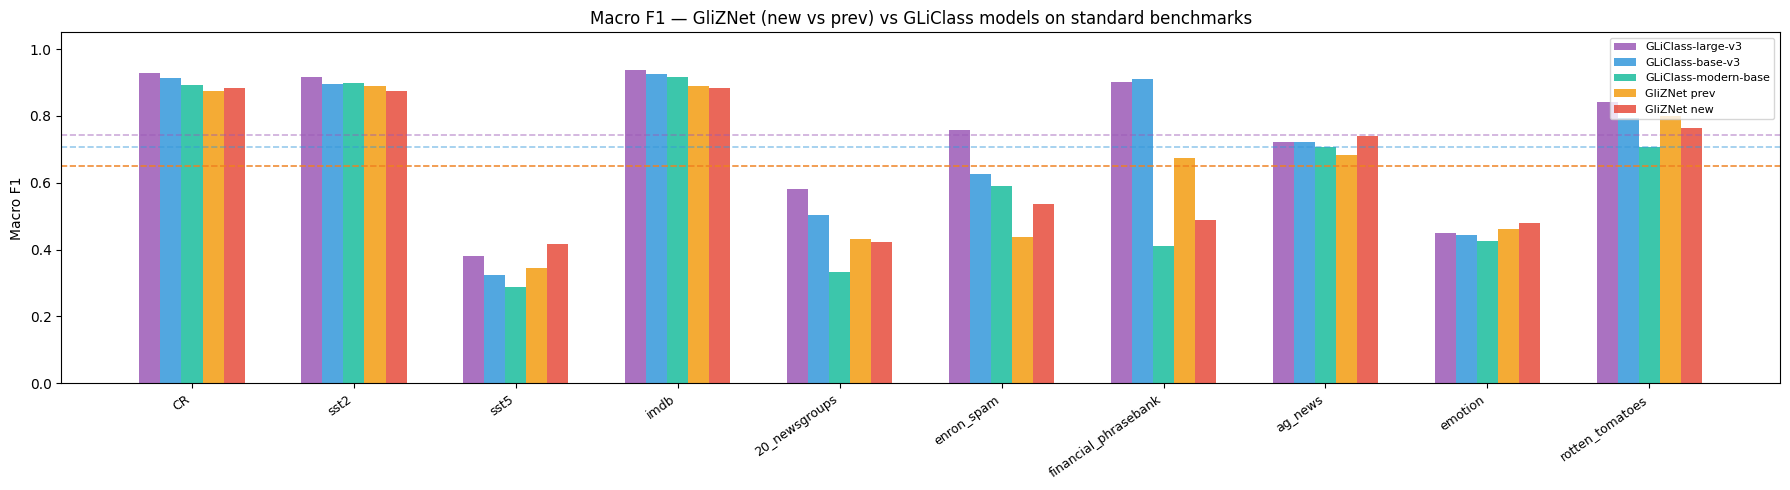


GliZNet new avg macro F1    : 0.6487
GliZNet prev avg macro F1   : 0.6487  (Δ +0.0000)
GLiClass-large avg          : 0.7417  (Δ -0.0929)
GLiClass-base avg           : 0.7056  (Δ -0.0569)
GLiClass-modern-base avg    : 0.6170  (Δ +0.0317)

Per-dataset regression (new − prev):
  ▲ CR                                       +0.0076
  ▼ sst2                                     -0.0141
  ▲ sst5                                     +0.0734
  ▼ imdb                                     -0.0078
  ▼ 20_newsgroups                            -0.0071
  ▲ enron_spam                               +0.0985
  ▼ financial_phrasebank                     -0.1848
  ▲ ag_news                                  +0.0550
  ▲ emotion                                  +0.0157
  ▼ rotten_tomatoes                          -0.0361


In [ ]:
plot_df = df.drop("AVERAGE").dropna()
x = np.arange(len(plot_df))
w = 0.11

fig, ax = plt.subplots(figsize=(20, 5))
cols   = ["GLiClass-large-v3", "GLiClass-base-v3", "GLiClass-modern-base",
          "GliZNet prev (ours)", "GliZNet+LCA no-pretrain", "GliZNet+LCA+polarity"]
labels = ["GLiClass-large", "GLiClass-base", "GLiClass-modern-base",
          "GliZNet prev", "GliZNet+LCA (no pretrain)", "GliZNet+LCA+polarity"]
colors = ["#9b59b6", "#3498db", "#1abc9c", "#95a5a6", "#f39c12", "#e74c3c"]
n = len(cols)
offsets = np.linspace(-(n-1)/2, (n-1)/2, n)

for off, col, lbl, clr in zip(offsets, cols, labels, colors):
    ax.bar(x + off * w, plot_df[col], w, label=lbl, color=clr, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1.05)
ax.set_title("Macro F1 — GliZNet ablation (prev / +LCA / +LCA+polarity) vs GLiClass")
ax.legend(loc="upper right", fontsize=8)

avgs = {col: df.loc["AVERAGE", col] for col in cols}
ax.axhline(avgs["GliZNet prev (ours)"],       color="#95a5a6", ls="--", lw=1.2, alpha=0.7)
ax.axhline(avgs["GliZNet+LCA no-pretrain"],   color="#f39c12", ls="--", lw=1.2, alpha=0.7)
ax.axhline(avgs["GliZNet+LCA+polarity"],      color="#e74c3c", ls="--", lw=1.2, alpha=0.7)
ax.axhline(avgs["GLiClass-base-v3"],          color="#3498db", ls="--", lw=1.2, alpha=0.5)
ax.axhline(avgs["GLiClass-large-v3"],         color="#9b59b6", ls="--", lw=1.2, alpha=0.5)

plt.tight_layout()
plt.show()

print(f"{'Model':<35} {'Avg F1':>8}  {'Δ vs prev':>10}")
print("─" * 57)
ref = avgs["GliZNet prev (ours)"]
for col, lbl in zip(cols, labels):
    a = avgs[col]
    print(f"  {lbl:<33} {a:.4f}  {a - ref:+.4f}")

print("\nPer-dataset: LCA impact (no-pretrain − prev):")
for ds_id in DATASETS:
    ds = ds_id.split("/")[-1]
    delta = df.loc[ds, "Δ LCA vs prev"]
    sign = "▲" if delta > 0 else "▼"
    print(f"  {sign} {ds:<40} {delta:+.4f}")

print("\nPer-dataset: polarity pretrain impact (polarity − no-pretrain):")
for ds_id in DATASETS:
    ds = ds_id.split("/")[-1]
    delta = df.loc[ds, "Δ polarity vs LCA"]
    sign = "▲" if delta > 0 else "▼"
    print(f"  {sign} {ds:<40} {delta:+.4f}")
